# Implementacion de una RNN para la prediccion del precio del Bitcoin

In [29]:
import tensorflow as tf
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
SEED = 42
tf.random.set_seed(SEED)

In [3]:
df = pd.DataFrame()

df = yf.download(
    "BTC-USD",
    start="2015-01-01",
    end="2026-05-04",
    interval="1d",
    auto_adjust=False
)
df = df.reset_index()

[*********************100%***********************]  1 of 1 completed


In [4]:
type(df)

pandas.core.frame.DataFrame

In [5]:
df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,2015-01-01,314.248993,314.248993,320.434998,314.002991,320.434998,8036550
1,2015-01-02,315.032013,315.032013,315.838989,313.565002,314.079010,7860650
2,2015-01-03,281.082001,281.082001,315.149994,281.082001,314.846008,33054400
3,2015-01-04,264.195007,264.195007,287.230011,257.612000,281.145996,55629100
4,2015-01-05,274.473999,274.473999,278.341003,265.084015,265.084015,43962800


In [6]:
df.tail()

Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
4136,2026-04-29,75776.132812,75776.132812,77884.968750,74958.570312,76350.687500,41460907886
4137,2026-04-30,76304.320312,76304.320312,76611.484375,75318.984375,75778.632812,29497862305
4138,2026-05-01,78179.000000,78179.000000,78894.976562,76294.695312,76305.054688,39164328894
4139,2026-05-02,78657.250000,78657.250000,79119.789062,78031.960938,78177.750000,16761531851
4140,2026-05-03,78538.226562,78538.226562,79402.359375,78073.078125,78656.726562,20544392639


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4141 entries, 0 to 4140
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   (Date, )              4141 non-null   datetime64[ns]
 1   (Adj Close, BTC-USD)  4141 non-null   float64       
 2   (Close, BTC-USD)      4141 non-null   float64       
 3   (High, BTC-USD)       4141 non-null   float64       
 4   (Low, BTC-USD)        4141 non-null   float64       
 5   (Open, BTC-USD)       4141 non-null   float64       
 6   (Volume, BTC-USD)     4141 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 226.6 KB


In [8]:
df.isna().sum()

Price      Ticker 
Date                  0
Adj Close  BTC-USD    0
Close      BTC-USD    0
High       BTC-USD    0
Low        BTC-USD    0
Open       BTC-USD    0
Volume     BTC-USD    0
dtype: int64

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10',
               ...
               '2026-04-24', '2026-04-25', '2026-04-26', '2026-04-27',
               '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01',
               '2026-05-02', '2026-05-03'],
              dtype='datetime64[ns]', name='Date', length=4141, freq=None)

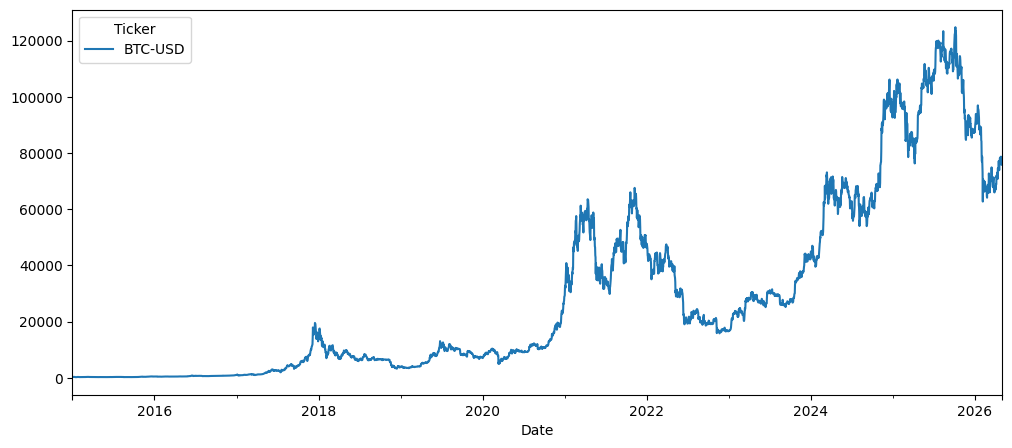

In [9]:
df=df.set_index('Date')
df['Close'].plot(figsize=(12,5))
df.index

In [10]:
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,4141.000000,4141.000000,4141.000000,4141.000000,4141.000000,4.141000e+03
mean,28982.568883,28982.568883,29542.498005,28352.580135,28964.720368,2.277116e+10
std,32390.487360,32390.487360,32933.075083,31797.029653,32385.051327,2.299022e+10
min,178.102997,178.102997,211.731003,171.509995,176.897003,7.860650e+06
25%,3865.952637,3865.952637,3939.373291,3789.919922,3862.266113,3.064030e+09
50%,11970.478516,11970.478516,12400.910156,11709.745117,11964.823242,1.842698e+10
75%,46456.058594,46456.058594,47512.027344,45244.714844,46445.273438,3.473036e+10
max,124752.531250,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


## Preprocesamiento del conjunto de datos

El preprocesamiento del conjunto de datos es crucial para el desarrollo de modelos de aprendizaje automático, especialmente en problemas de series temporales como la predicción del precio del Bitcoin. En esta sección, prepararemos nuestros datos para el entrenamiento de la Red Neuronal Recurrente (RNN) realizando las siguientes tareas de preprocesamiento:

1. Selección de características.
2. División de datos: Dividiremos nuestros datos en tres conjuntos: entrenamiento, validación y prueba. Ojo, realiza la separación respetando el orden temporal ya que se trata de una serie temporal.
3. Normalización: Normalizaremos los datos para que todas las características estén en la misma escala. Esto ayuda al modelo a converger más rápido durante el entrenamiento y a evitar problemas numéricos.
4. Prepara los datos en un array 3D. [batch, timesteps, feature]. Utiliza la aproximación sliding window.

In [11]:
df = df.reset_index() # Quitamos Date como indice para que sea una columna
df = df[['Date','Close']]

In [12]:
# No usaremos la funcion de train_tyest_split para respetar el orden temporal de los datos.

train_size = int(len(df)*0.6)
val_size = int(len(df)*0.2)
test_size = len(df) - train_size - val_size

print('Tamaño entrenamiento: ', train_size)
print('Tamaño validacion:', val_size)
print('Tamaño test:', test_size)

train_data = df[:train_size]
val_data = df[train_size:train_size+val_size]
test_data = df[train_size+val_size:]


Tamaño entrenamiento:  2484
Tamaño validacion: 828
Tamaño test: 829


In [13]:
scaler = MinMaxScaler(feature_range=(0,1))

X_train = scaler.fit_transform(train_data.Close)
X_val = scaler.transform(val_data.Close)
X_test = scaler.transform(test_data.Close)

In [14]:
def create_dataset(data, time_steps):
    """
    Crea un conjunto de datos estructurado para el entrenamiento de una RNN.

    Argumentos:
    data: Array numpy, conjunto de datos de series temporales.
    time_steps: Entero, número de pasos temporales anteriores a considerar para predecir el siguiente.

    Retorna:
    X: Array numpy, conjunto de datos de características con n timesteps.
    y: Array numpy, conjunto de datos de etiquetas correspondientes a la siguiente observación después de los n timesteps.
    """
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i - time_steps:i, 0])
        y.append(data[i, 0])

    return np.expand_dims(np.array(X), axis=-1), np.array(y)

In [15]:
WINDOW = 365 # Aplicamos una ventana de 1 año

X_train, y_train = create_dataset(X_train,WINDOW)
X_val, y_val = create_dataset(X_val,WINDOW)
X_test, y_test = create_dataset(X_test,WINDOW)

In [16]:
X_train.shape

(2119, 365, 1)

# Entrenamiento

Se pide que se explore el entrenamiento de un modelo recurrente explorando los tipos de nueronas GRU,LST, la bidireccionalidad y las stacked RNN

## LSTM

In [22]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],X_train.shape[2])))
model.add(LSTM(128))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='relu'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,873 (296.38 KB)

 Trainable params: 75,873 (296.38 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer='adam', loss='mean_squared_error')
callbacks = [EarlyStopping(patience=3)]

In [27]:
model.fit(
    X_train,y_train,
    epochs= 20,
    batch_size=32,
    callbacks = callbacks,
    validation_data=(X_val,y_val)
)

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0084 - val_loss: 0.0031
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0019 - val_loss: 3.3305e-04
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.0011 - val_loss: 3.6202e-04


In [28]:
print('MSE train:', model.evaluate(X_train,y_train))
print('MSE val:', model.evaluate(X_val,y_val))
print('MSE test', model.evaluate(X_test,y_test))

67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 3.5417e-04
MSE train: 0.0003541709447745234
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 3.6202e-04
MSE val: 0.00036201628972776234
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0077
MSE test 0.0076643312349915504


67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


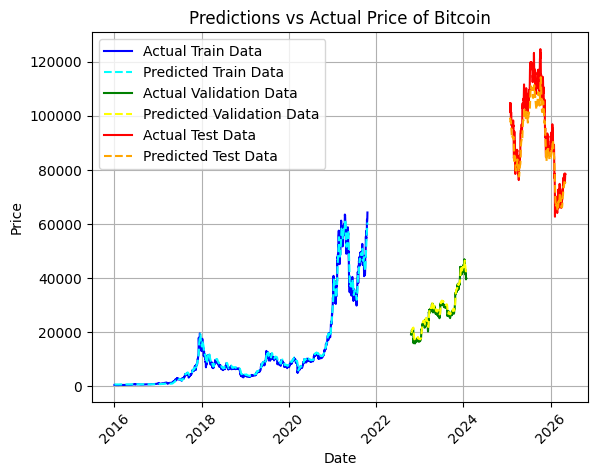

In [30]:
y_pred_train = scaler.inverse_transform(model.predict(X_train))
y_pred_val = scaler.inverse_transform(model.predict(X_val))
y_pred_test = scaler.inverse_transform(model.predict(X_test))

# Training data
plt.plot(
    train_data['Date'][WINDOW:],
    scaler.inverse_transform(y_train.reshape(-1, 1)),
    color='blue',
    label='Actual Train Data'
)
plt.plot(
    train_data['Date'][WINDOW:],
    y_pred_train,
    color='cyan',
    linestyle='--',
    label='Predicted Train Data'
)

# Validation data
plt.plot(
    val_data['Date'][WINDOW:],
    scaler.inverse_transform(y_val.reshape(-1, 1)),
    color='green',
    label='Actual Validation Data'
)
plt.plot(
    val_data['Date'][WINDOW:],
    y_pred_val,
    color='yellow',
    linestyle='--',
    label='Predicted Validation Data'
)

# Test data
plt.plot(
    test_data['Date'][WINDOW:],
    scaler.inverse_transform(y_test.reshape(-1, 1)),
    color='red',
    label='Actual Test Data'
)
plt.plot(
    test_data['Date'][WINDOW:],
    y_pred_test,
    color='orange',
    linestyle='--',
    label='Predicted Test Data'
)

plt.title('Predictions vs Actual Price of Bitcoin')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()